In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
filepath = '../benchmark_datasets/CACHE5/20240430_MCHR1_splitted_RJ.csv'
df = pd.read_csv(filepath, index_col=0)
df.head()
from rdkit import Chem
def compute_heavy_atom_count(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return mol.GetNumHeavyAtoms() if mol else None

df["HAC"] = df["smiles"].apply(compute_heavy_atom_count)

In [38]:
positive_labels = df[df["class"] == 1]
positive_labels

,aid,cid,acname,smiles,exp_type,source,acvalue_uM,class,ID,random_10f,DataSAIL_10f,HAC
Unnamed: 0,,,,,,,,,,,,
0,262800,10128900,pKi,CN1CCN(CCCCN(C(=O)Nc2ccc(F)c(C(F)(F)F)c2)[C@@H...,displacement,patent,8.657577,1,ID00000,Fold_0,Fold_9,40
1,262800,10174940,pKi,N#Cc1cccc([C@]23CC[C@@H](N(CCCCN4CCCCC4)C(=O)N...,displacement,patent,8.795880,1,ID00001,Fold_8,Fold_9,39
2,262800,10195637,pKi,N#Cc1cccc([C@]23CC[C@@H](N(CCN4CCCCC4)C(=O)Nc4...,displacement,patent,8.387216,1,ID00002,Fold_8,Fold_9,34
4,262800,10239907,pKi,CC(C)CN1CCN(CCN(C(=O)Nc2ccc(F)c(C(F)(F)F)c2)[C...,displacement,patent,8.045757,1,ID00004,Fold_8,Fold_9,41
5,262800,10289615,pKi,N#Cc1cccc([C@]23CC[C@@H](N(CCCCN4CCOCC4)C(=O)N...,displacement,patent,8.602060,1,ID00005,Fold_8,Fold_9,39
...,...,...,...,...,...,...,...,...,...,...,...,...
2995,19288562,CHEMBL4410510,pIC50,CN(C)CCC(CNC(=O)Nc1cc(F)cc(F)c1)c1ccc(-c2cccc(...,antagonist activity,chembl,6.055517,1,ID02995,Fold_0,Fold_5,33
2996,19288563,CHEMBL4410510,pIC50,CN1CCC(CNC(=O)Nc2ccccc2)(c2ccc(-c3cccc(C#N)c3)...,antagonist activity,chembl,5.657577,1,ID02996,Fold_8,Fold_5,32
2997,19288565,CHEMBL4410510,pIC50,CN(C)CCC(CNC(=O)Nc1ccccc1)c1ccc(-c2cccc(C#N)c2...,antagonist activity,chembl,5.585027,1,ID02997,Fold_0,Fold_5,31


/tmp/ipykernel_785372/3237406194.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(positive_labels['acvalue_uM'],shade=True)


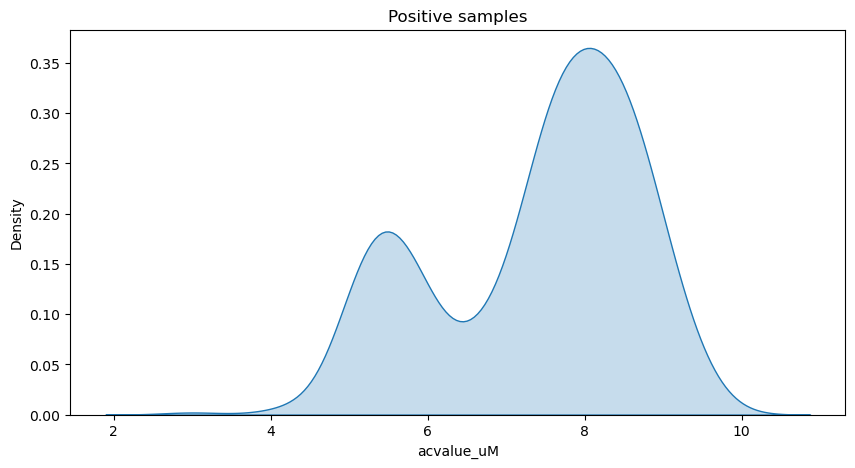

Max ac_Value =  9.769551078621726


In [39]:
plt.figure(figsize=(10,5))
plt.xlabel('acvalue_uM')
plt.ylabel('Density')
sns.kdeplot(positive_labels['acvalue_uM'],shade=True)
plt.title("Positive samples")
plt.show()

print("Max ac_Value = ", positive_labels['acvalue_uM'].max())

/tmp/ipykernel_785372/2270717806.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(neg_df['acvalue_uM'],shade=True)


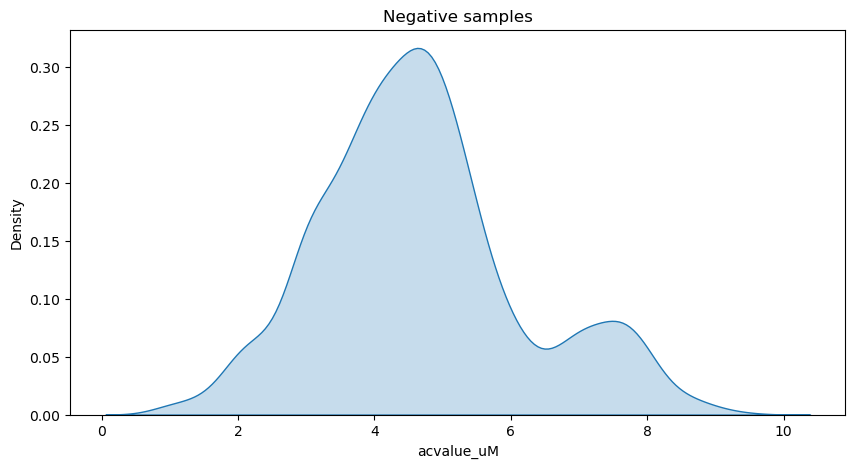

Max ac_Value =  9.443697499232712


In [40]:
neg_df = df[df["class"] != 1]
plt.figure(figsize=(10,5))
plt.xlabel('acvalue_uM')
plt.ylabel('Density')
sns.kdeplot(neg_df['acvalue_uM'],shade=True)
plt.title("Negative samples")
plt.show()

print("Max ac_Value = ", neg_df['acvalue_uM'].max())

/tmp/ipykernel_785372/2465716919.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df['acvalue_uM'],shade=True)


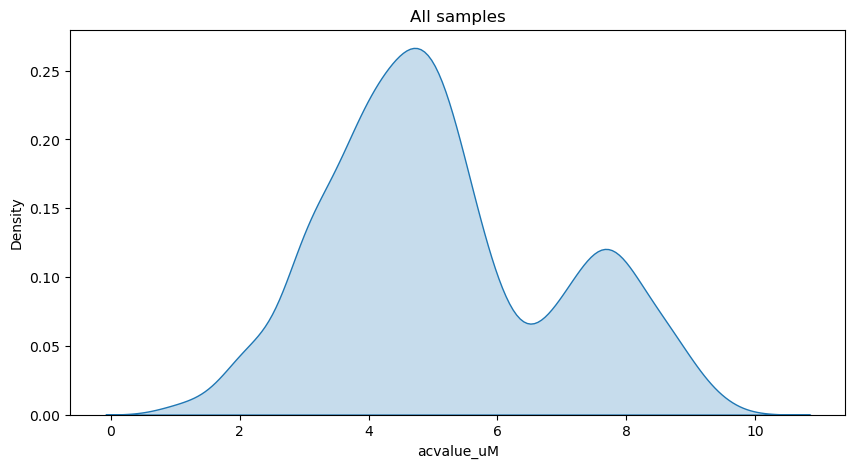

In [41]:
plt.figure(figsize=(10,5))
plt.xlabel('acvalue_uM')
plt.ylabel('Density')
sns.kdeplot(df['acvalue_uM'],shade=True)
plt.title("All samples")
plt.show()

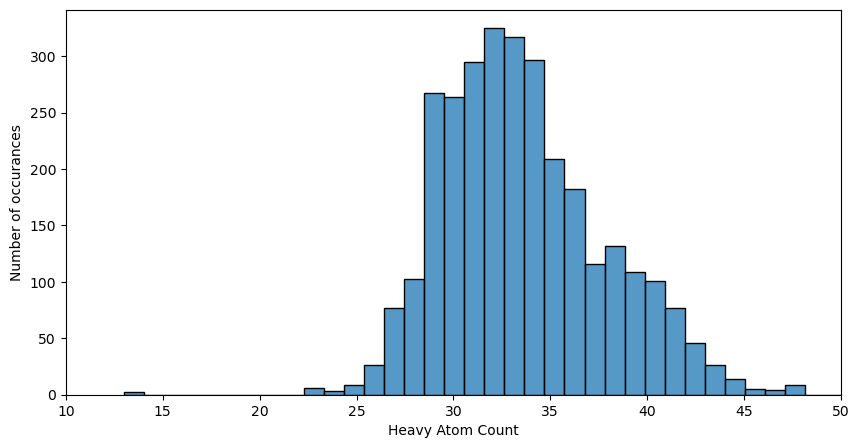

In [42]:
plt.figure(figsize=(10,5))
plt.xlim(10,50)
plt.xlabel('Heavy Atom Count')
plt.ylabel('Number of occurances')
sns.histplot(df['HAC'], bins = 150, kde=False)
plt.show()

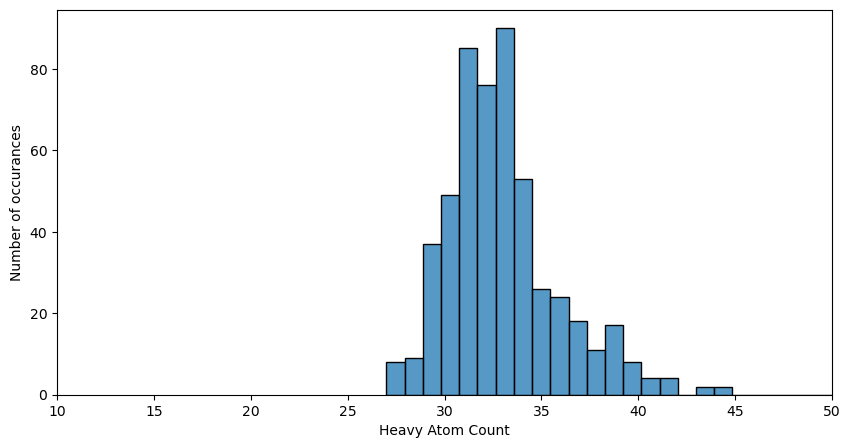

In [43]:
plt.figure(figsize=(10,5))
plt.xlim(10,50)
plt.xlabel('Heavy Atom Count')
plt.ylabel('Number of occurances')
sns.histplot(positive_labels['HAC'], bins = 150, kde=False)
plt.show()

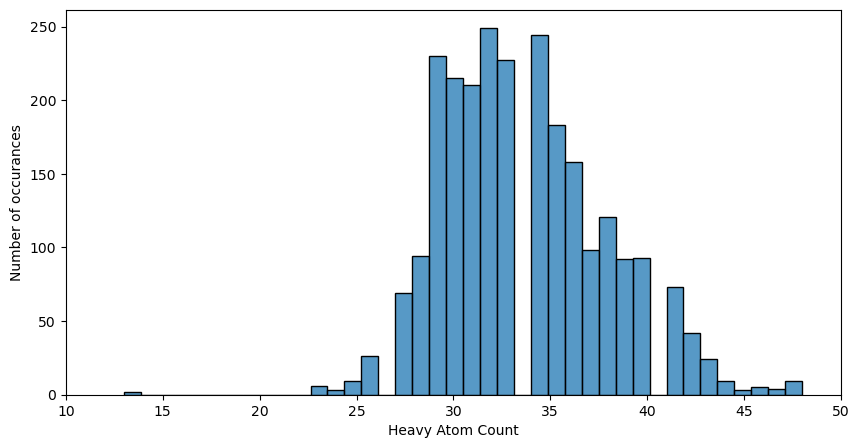

In [45]:
plt.figure(figsize=(10,5))
plt.xlim(10,50)
plt.xlabel('Heavy Atom Count')
plt.ylabel('Number of occurances')
sns.histplot(neg_df['HAC'], kde=False)
plt.show()

In [46]:
df["HAC"].mean(), df["HAC"].std()

(33.56911375661376, 5.869897055364571)

In [47]:
33 + (1.9*5.8), 33 - (1.9*5.8) 

(44.019999999999996, 21.98)

In [51]:
from scipy.stats import sem, t
from scipy.stats import norm
hac_data = df["HAC"]
# Calculate the mean
# Compute statistics
mean_hac = np.mean(hac_data)
std_hac = np.std(hac_data, ddof=1)  # Sample standard deviation
n = len(hac_data)

# Compute 95% confidence interval
z_critical = norm.ppf(0.975)  # Z-critical value for 95% confidence
margin_of_error = z_critical * (std_hac / np.sqrt(n))
lower_bound = mean_hac - margin_of_error
upper_bound = mean_hac + margin_of_error

print(f"Mean HAC: {mean_hac:.2f}")
print(f"95% Confidence Interval for HAC: ({lower_bound:.2f}, {upper_bound:.2f})")

Mean HAC: 33.57
95% Confidence Interval for HAC: (33.36, 33.78)


In [52]:
hac_data

Unnamed: 0
0       40
1       39
2       34
3       34
4       41
        ..
3019    23
3020    23
3021    23
3022    29
3023    27
Name: HAC, Length: 3024, dtype: int64